# P4_Final Assignment

In [1]:
#importing

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import LogLocator, NullFormatter
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 11,
})


In [2]:
#loading files

bathy_file = "gebco_2025_n-32.0_s-35.0_w17.0_e20.0.nc"
chl_file = "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc"

bathy = xr.open_dataset(bathy_file)
chl_full = xr.open_dataset(chl_file)

if "lon" in chl_full.coords and np.any(np.diff(chl_full["lon"].values) < 0):
    chl_full = chl_full.sortby("lon")
if "lat" in chl_full.coords and np.any(np.diff(chl_full["lat"].values) < 0):
    chl_full = chl_full.sortby("lat")

if "lon" in bathy.coords and np.any(np.diff(bathy["lon"].values) < 0):
    bathy = bathy.sortby("lon")
if "lat" in bathy.coords and np.any(np.diff(bathy["lat"].values) < 0):
    bathy = bathy.sortby("lat")

print(chl_full)
print(bathy)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB -89.98 -89.94 -89.9 -89.85 ... 89.9 89.94 89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
 

# Bathmetry File

For bathymetry I worked with the netCDF file from GEBCO instead of GMRT because bathymetry data from GMRT was missing in some rgions.

In [3]:
#defining the region

LON_MIN, LON_MAX = 17, 20
LAT_MIN, LAT_MAX = -35, -32

chl = chl_full["chlor_a"].sel(
    lon=slice(LON_MIN, LON_MAX),
    lat=slice(LAT_MIN, LAT_MAX)
)

depth = bathy["elevation"].sel(
    lon=slice(LON_MIN, LON_MAX),
    lat=slice(LAT_MIN, LAT_MAX)
)

print("Chl subset shape:", chl.shape)
print("Bathymetry subset shape:", depth.shape)

Chl subset shape: (12, 72, 72)
Bathymetry subset shape: (720, 720)


# Region

I chose to work in the benguela upwelling system because of the high productivity that takes place in the region.

In [4]:
chl_positive = chl.where(chl > 0)

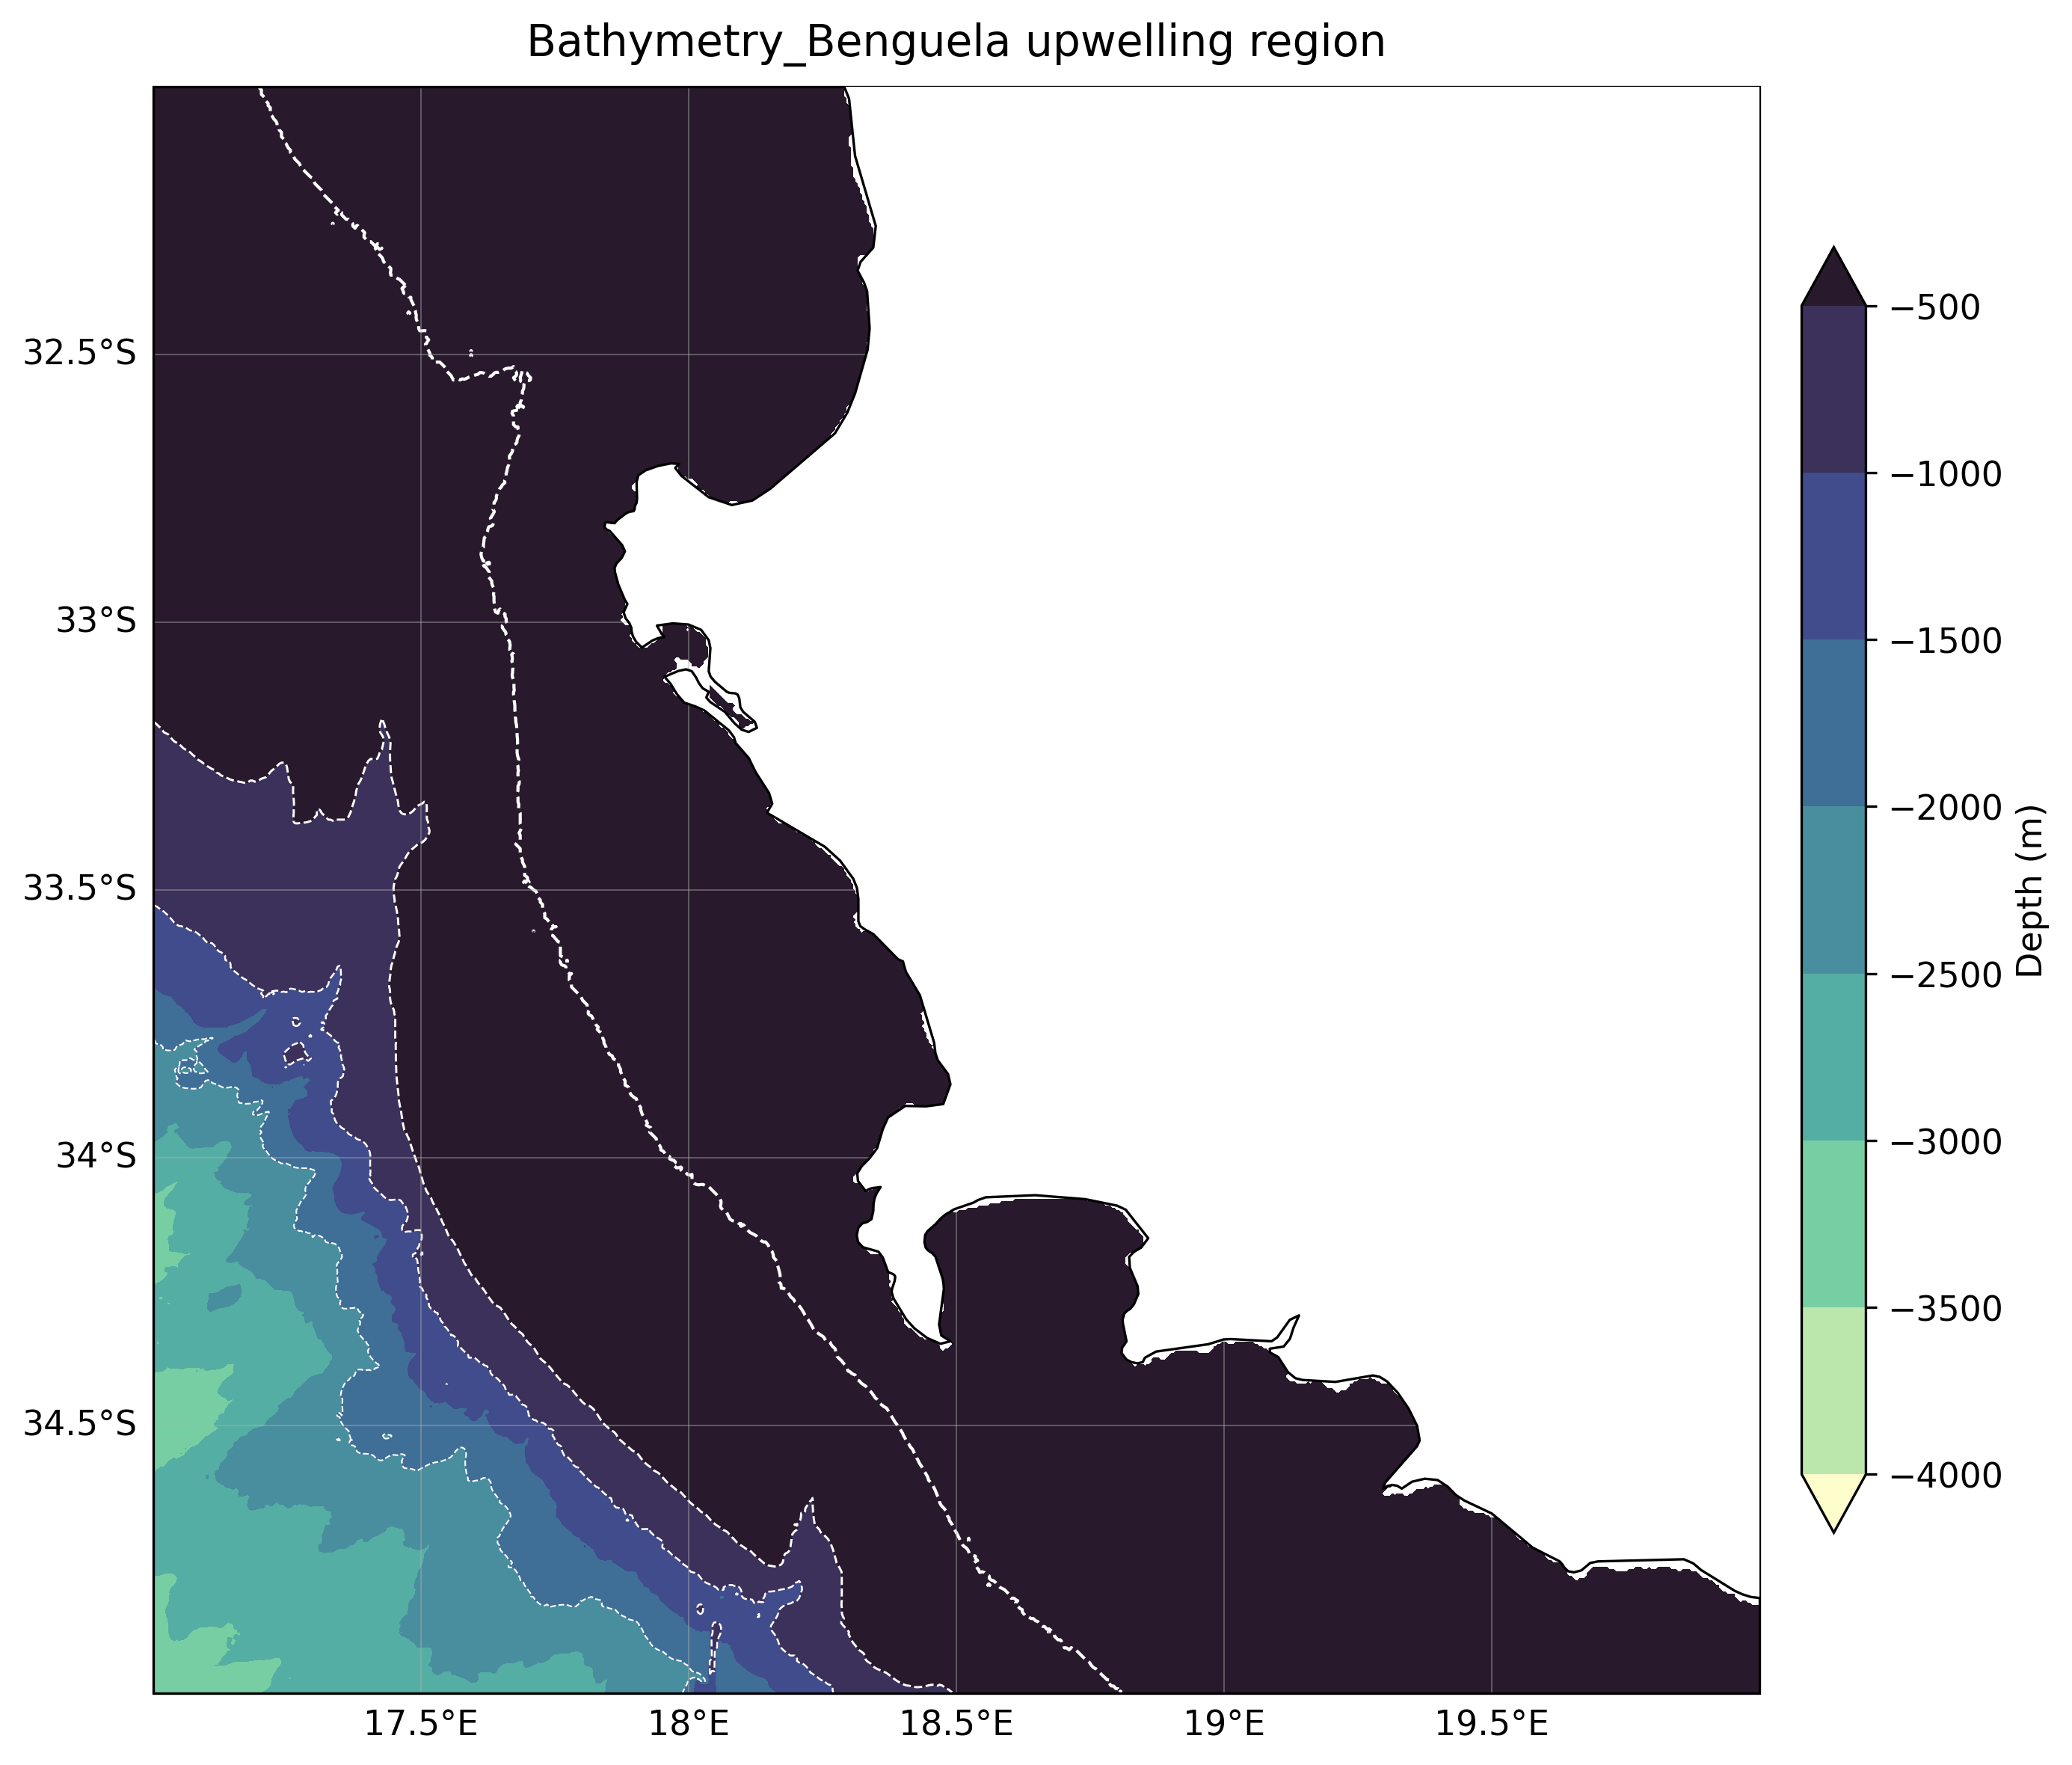

In [5]:
#Bathymetry plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})

depth_plot = depth.where(depth < 0)

levels = np.arange(-4000, 0, 500)

im = depth_plot.plot.contourf(
    ax=ax,
    levels=levels,
    cmap=cmocean.cm.deep,
    extend="both",
    add_colorbar=True,
    cbar_kwargs={"label": "Depth (m)", "shrink": 0.8, "pad": 0.02}
)

#adding contours
depth_plot.plot.contour(
    ax=ax,
    levels=[-2000, -1000, -500, -200],
    colors="white",
    linewidths=[0.5, 0.6, 0.7, 1.0],
    add_labels=False
)

ax.add_feature(cfeature.LAND, facecolor="white", zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])

gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title("Bathymetry_Benguela upwelling region", fontsize=14, pad=10)
plt.tight_layout()
plt.savefig("Bathymetry.png", bbox_inches="tight")
plt.show()

# Contours in the bathymetry map

I added contours in attemp to show the differences in depths in the region.

In [6]:
chl_annual = chl.where(chl > 0).mean(dim="time")

In [7]:
chl_annual = chl_annual.where(chl_annual > 0)

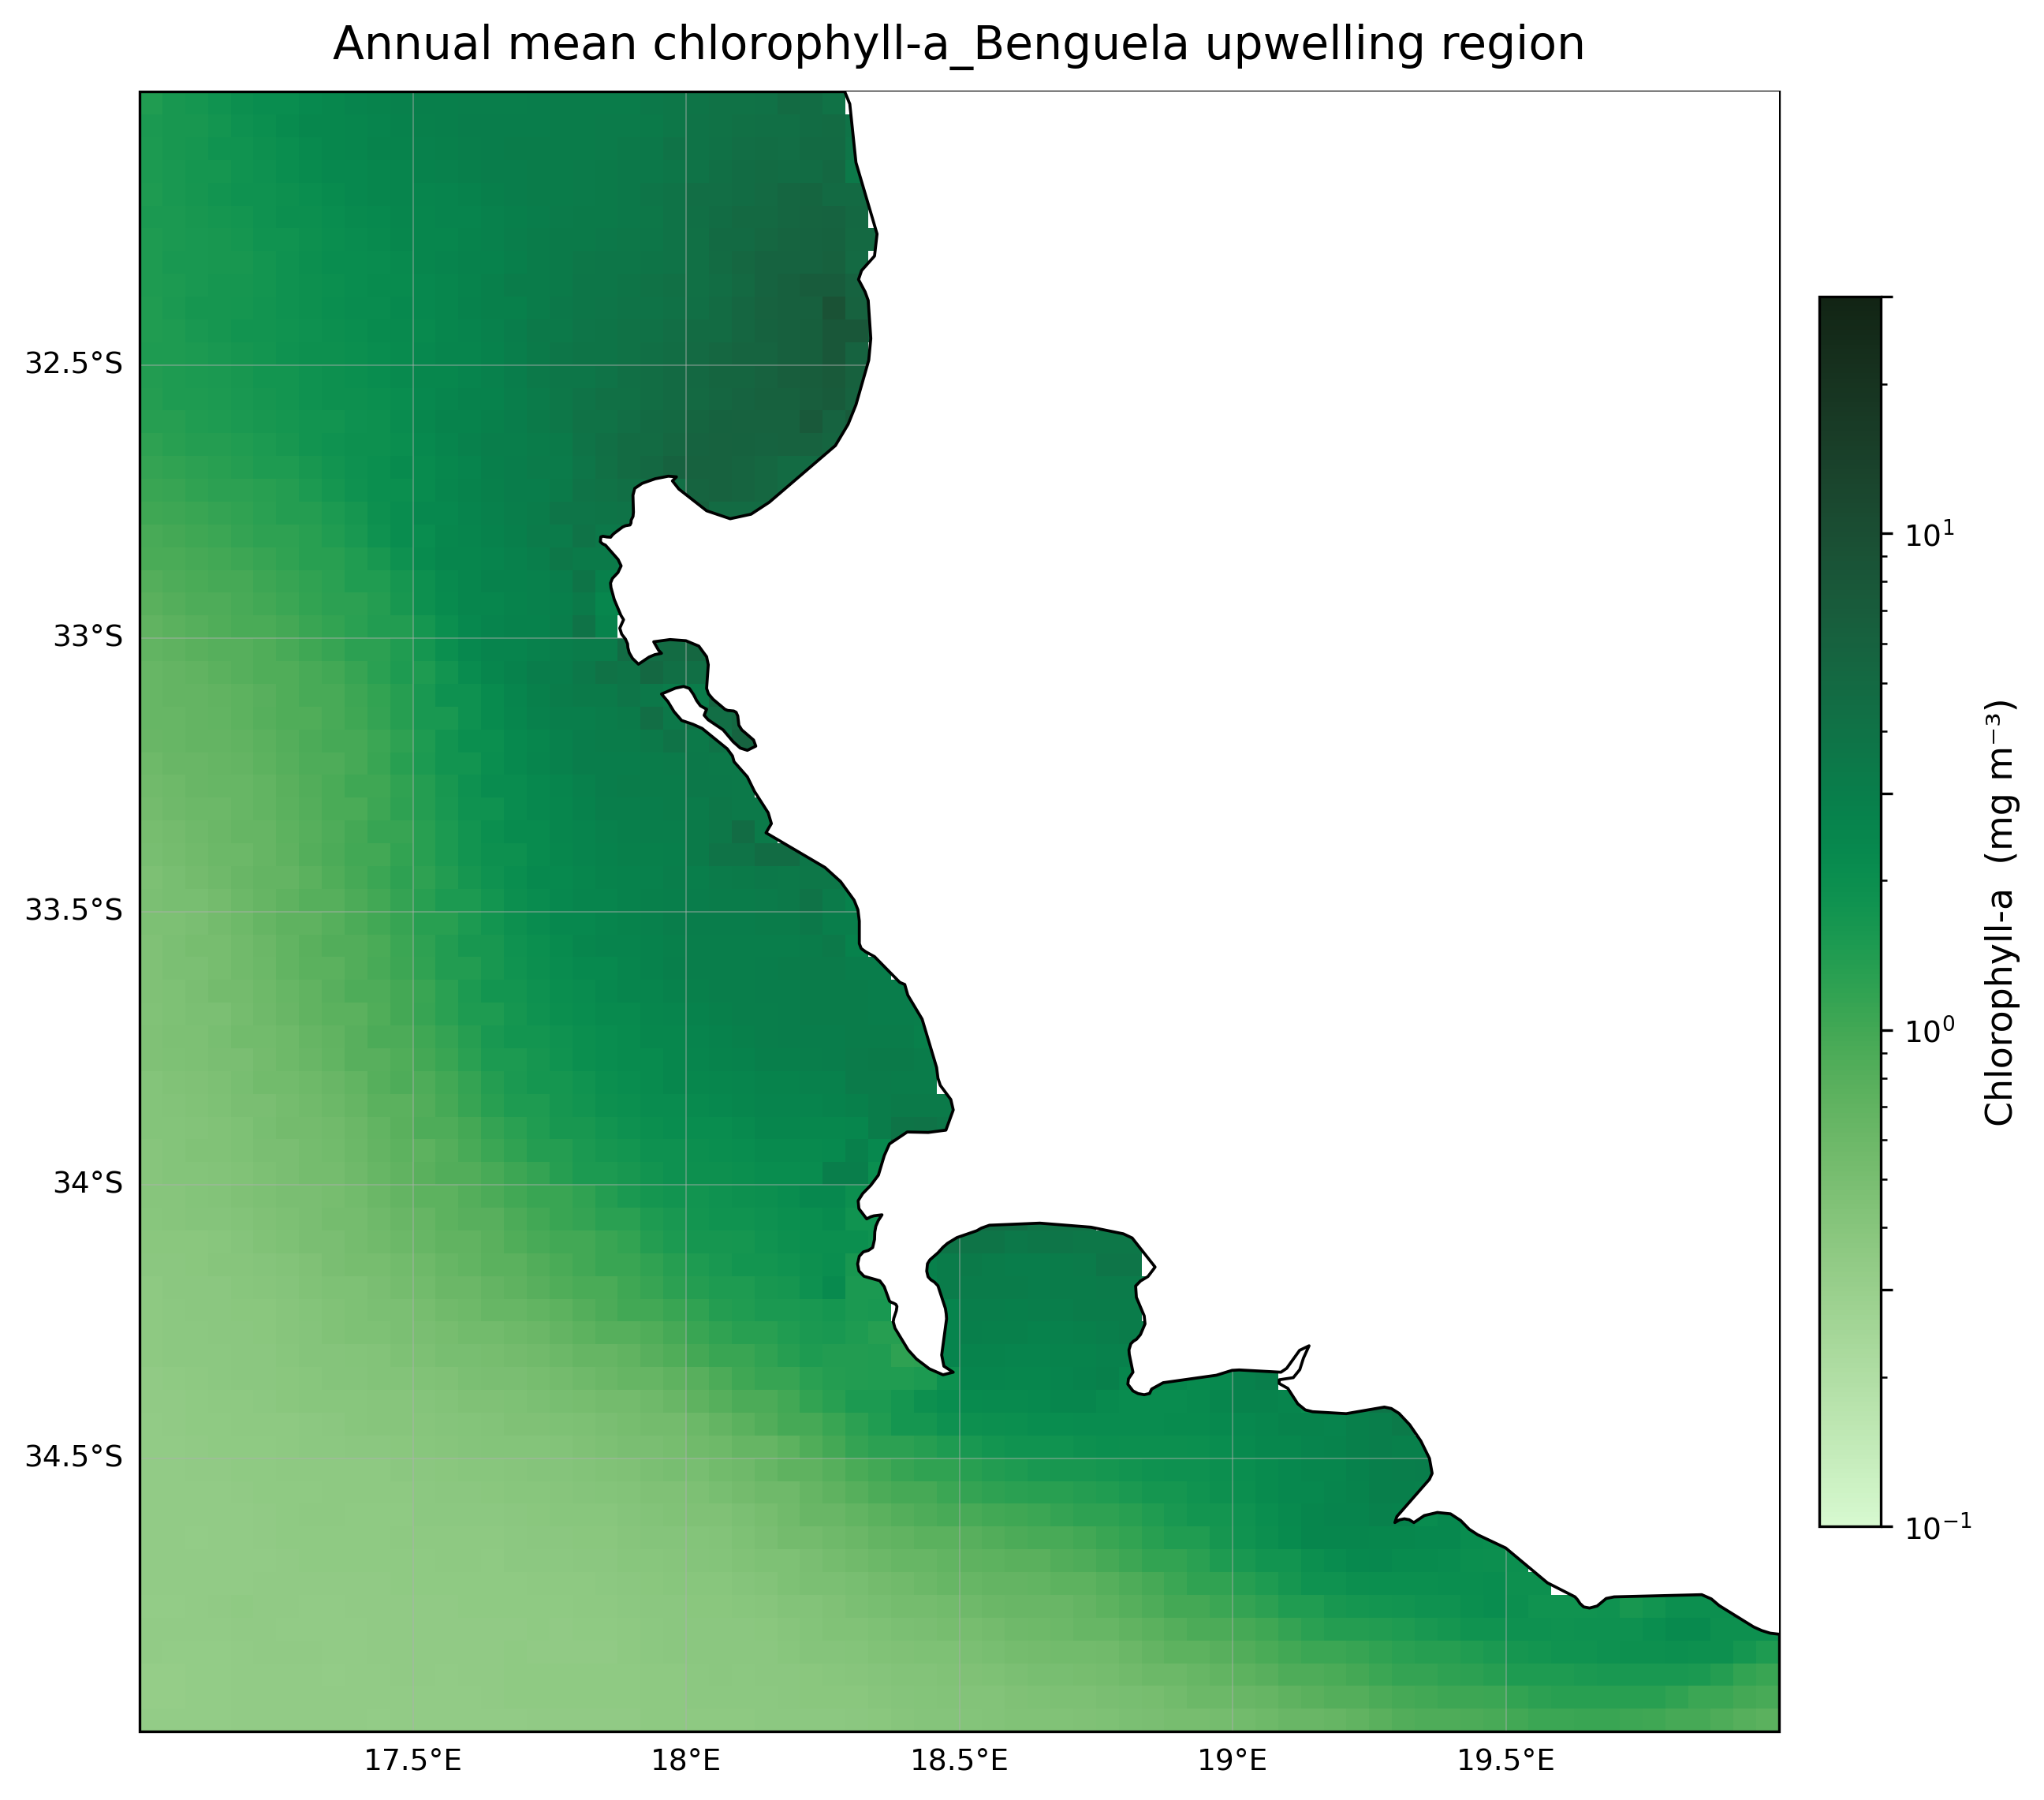

In [8]:
lons = chl_annual.lon.values
lats = chl_annual.lat.values
data = chl_annual.values
data = np.where(data <= 0, np.nan, data)

fig, ax = plt.subplots(1, 1, figsize=(11, 9),
                        subplot_kw={"projection": ccrs.PlateCarree()})

norm = mcolors.LogNorm(vmin=0.1, vmax=30)

mesh = ax.pcolormesh(
    lons, lats, data,
    cmap=cmocean.cm.algae,
    norm=norm,
    shading="nearest",
    transform=ccrs.PlateCarree(),
    zorder=1,
    rasterized=True
)

ax.add_feature(cfeature.LAND, facecolor="white", zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.9, zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=4)

cbar = plt.colorbar(mesh, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Chlorophyll-a  (mg m⁻³)", fontsize=11)
cbar.set_ticks([0.1, 0.3, 1, 3, 10, 30])
cbar.ax.tick_params(labelsize=9)

ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
ax.set_title("Annual mean chlorophyll-a_Benguela upwelling region",
             fontsize=14, pad=10)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5, linestyle="-")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

plt.savefig("Annual_mean_chl.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

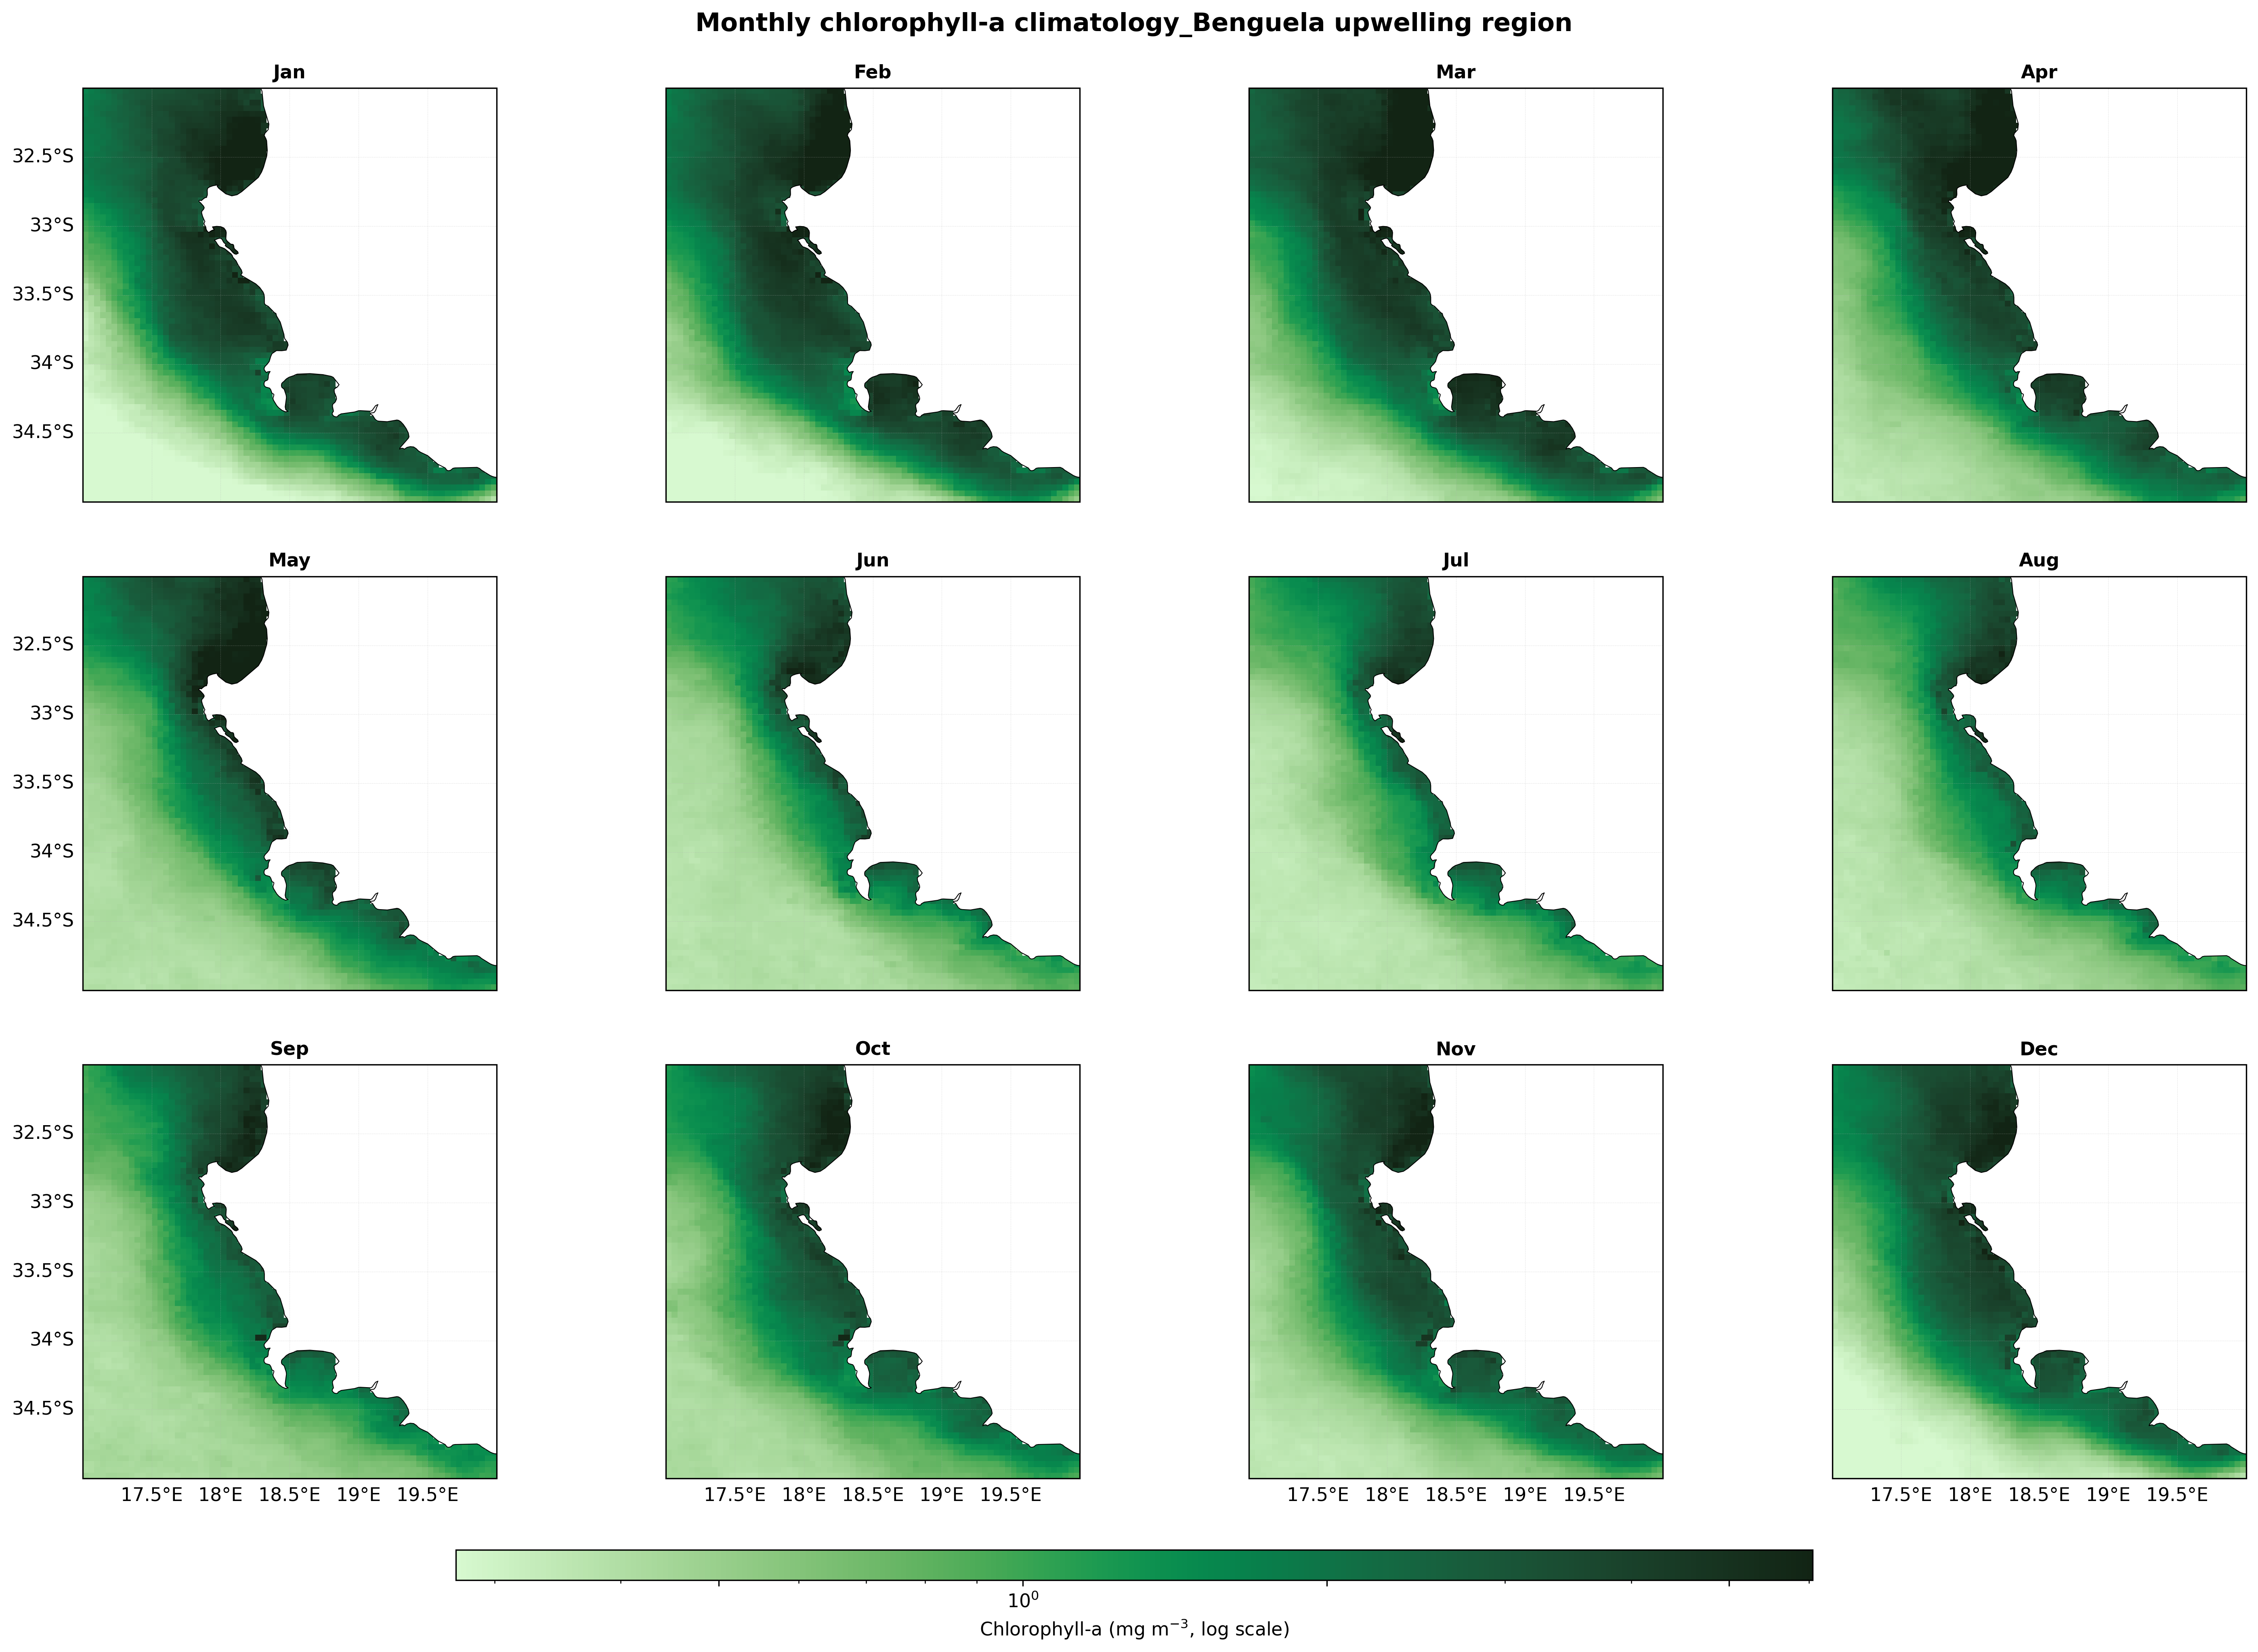

In [10]:
monthly_vals = chl_positive.values
monthly_vals = monthly_vals[np.isfinite(monthly_vals) & (monthly_vals > 0)]

vmin_monthly = np.nanpercentile(monthly_vals, 2)
vmax_monthly = np.nanpercentile(monthly_vals, 98)
vmin_monthly = max(vmin_monthly, 0.03)
vmax_monthly = max(vmax_monthly, vmin_monthly * 8)

norm_monthly = mcolors.LogNorm(vmin=vmin_monthly, vmax=vmax_monthly)

fig, axes = plt.subplots(
    3, 4, figsize=(20, 14),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=False
)

for i, ax in enumerate(axes.flat):
    month_data = chl_positive.isel(time=i)

    mesh = ax.pcolormesh(
        month_data.lon,
        month_data.lat,
        month_data,
        cmap=cmocean.cm.algae,
        norm=norm_monthly,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.LAND, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
    ax.set_title(months[i], fontsize=11, fontweight="bold")

    gl = ax.gridlines(linewidth=0.2, alpha=0.4, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    row, col = divmod(i, 4)
    gl.left_labels = (col == 0)
    gl.bottom_labels = (row == 2)

fig.subplots_adjust(left=0.04, right=0.985, top=0.93, bottom=0.11, wspace=0.08, hspace=0.18)

cax = fig.add_axes([0.22, 0.05, 0.56, 0.018])
cbar = fig.colorbar(mesh, cax=cax, orientation="horizontal")
cbar.set_label("Chlorophyll-a (mg m$^{-3}$, log scale)")

cbar.locator = LogLocator(base=10, subs=(1.0, 2.0, 5.0), numticks=8)
cbar.update_ticks()
cbar.ax.xaxis.set_minor_formatter(NullFormatter())

fig.suptitle(
    "Monthly chlorophyll-a climatology_Benguela upwelling region",
    fontsize=15, fontweight="bold", y=0.975
)

plt.savefig("Monthly_chl.png", bbox_inches="tight", dpi=300)
plt.show()


Nearest grid point: lat=-33.812, lon=18.188


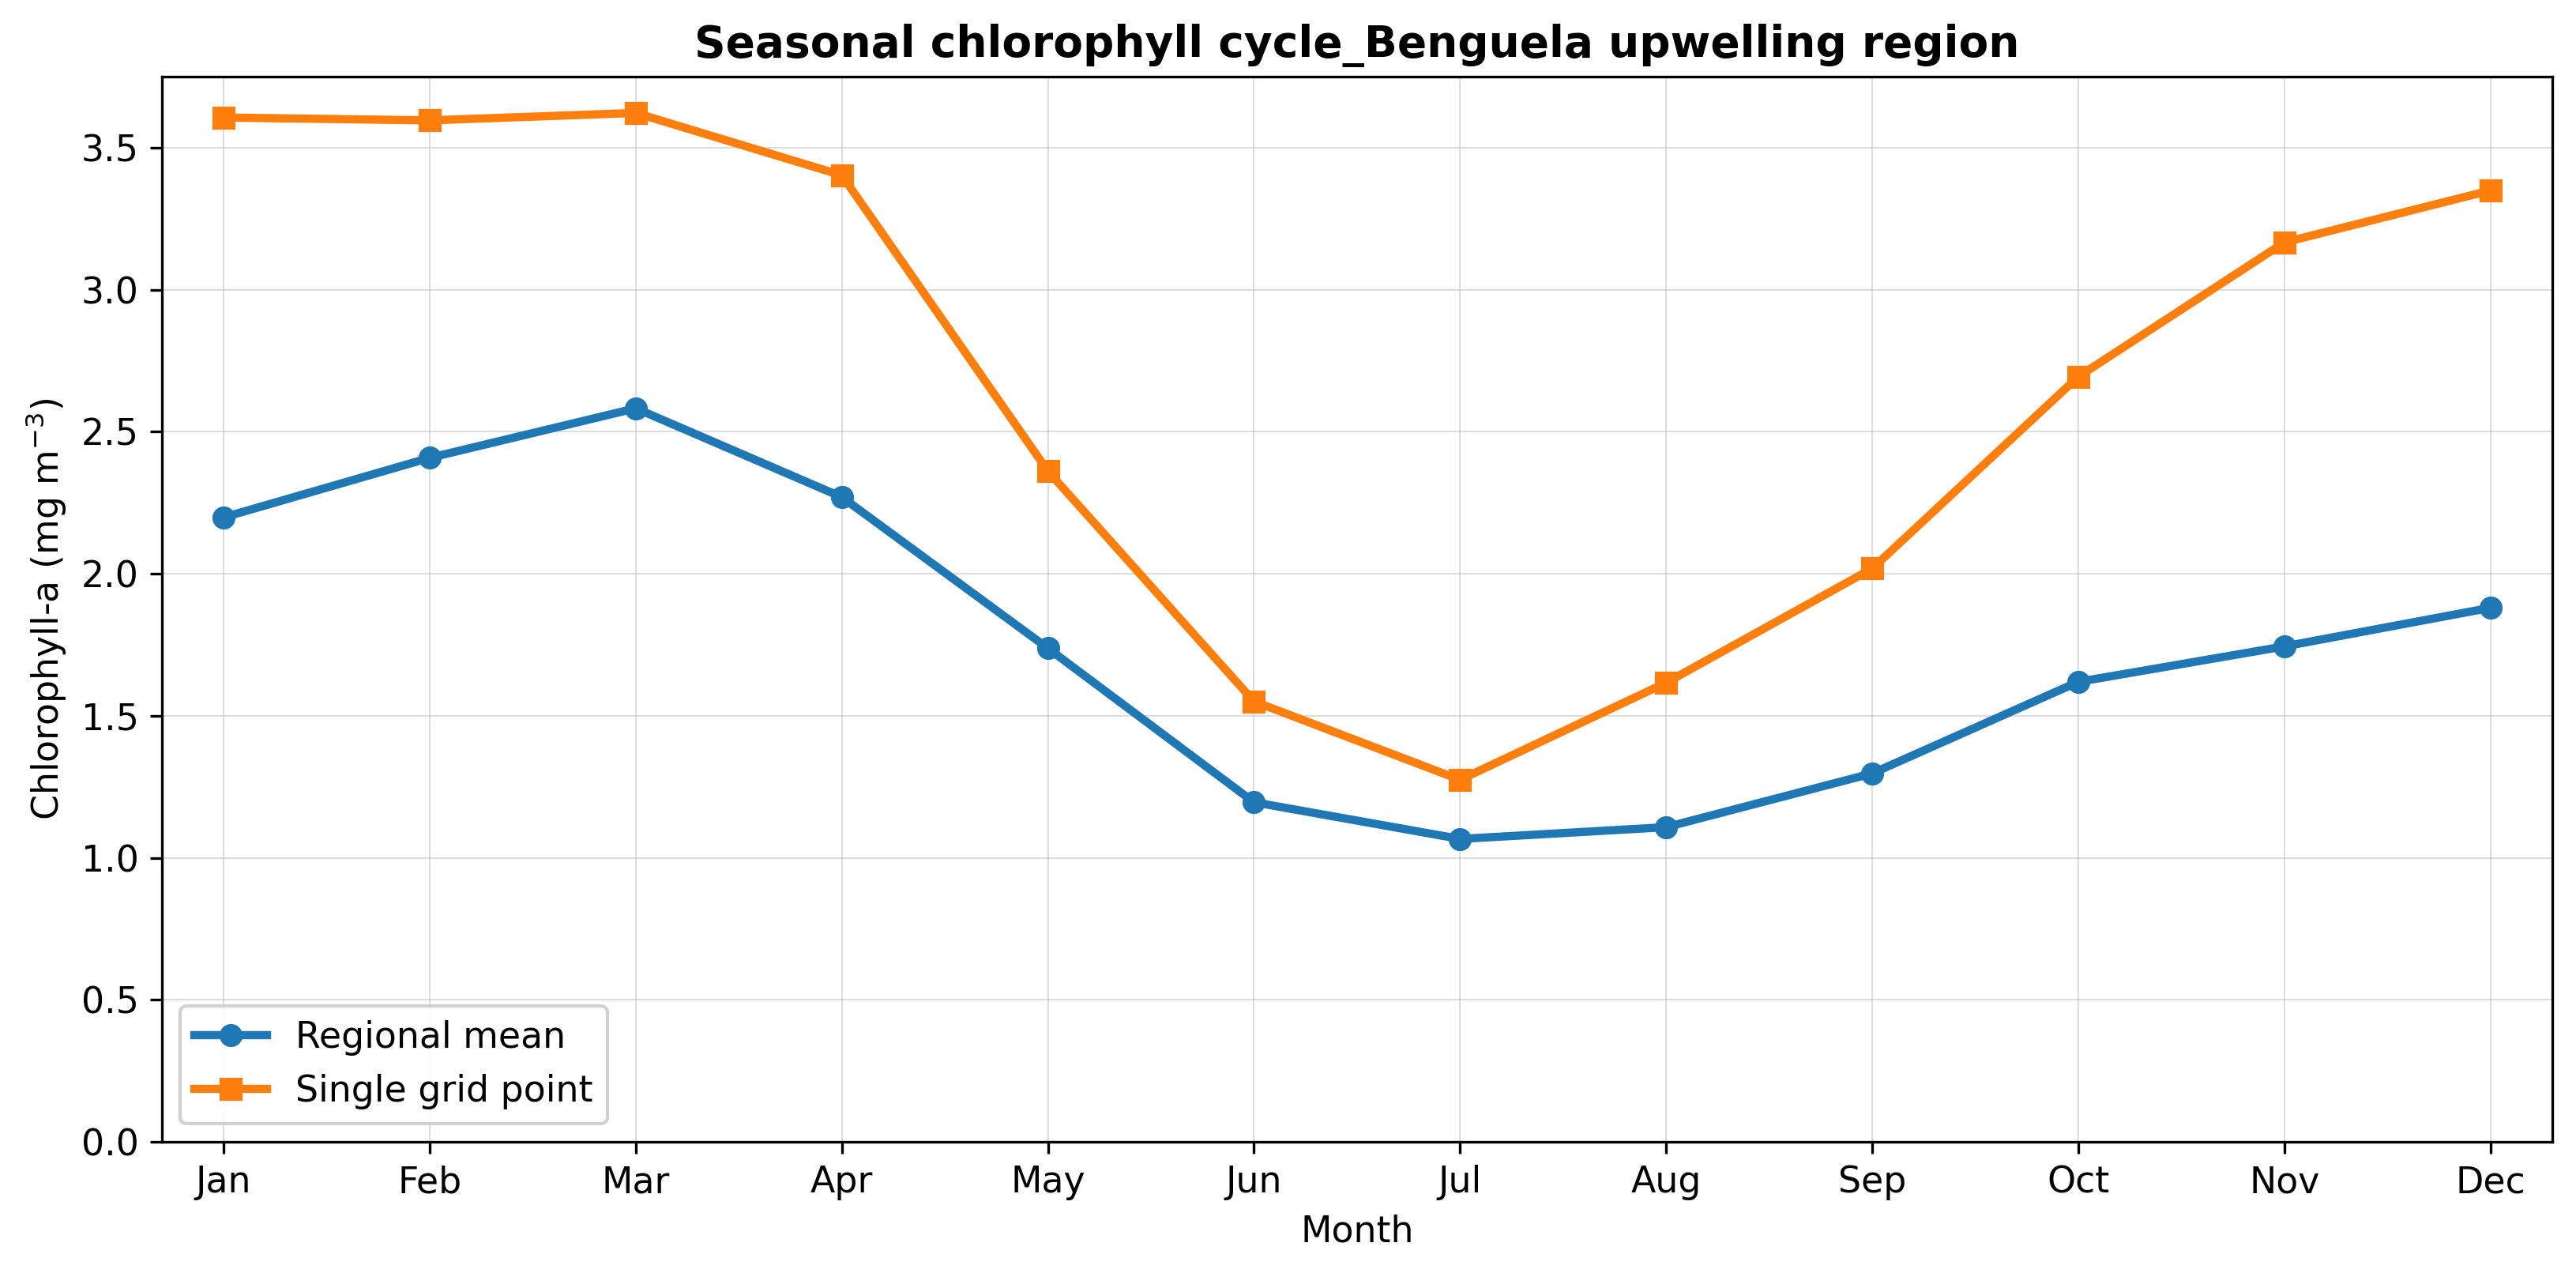

In [11]:
chl_regional = chl_positive.mean(dim=["lat", "lon"])

PT_LAT, PT_LON = -33.8, 18.2
chl_point = chl_positive.sel(lat=PT_LAT, lon=PT_LON, method="nearest")

print(
    f"Nearest grid point: lat={float(chl_point.lat):.3f}, "
    f"lon={float(chl_point.lon):.3f}"
)

regional_vals = chl_regional.values.astype(float)
point_vals = chl_point.values.astype(float)

x = np.arange(1, 13)

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    x, regional_vals,
    lw=2.5, marker="o", ms=6,
    label="Regional mean"
)

ax.plot(
    x, point_vals,
    lw=2.5, ls="-", marker="s", ms=6,
    label="Single grid point"
)

ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_ylabel("Chlorophyll-a (mg m$^{-3}$)")
ax.set_xlabel("Month")
ax.set_title("Seasonal chlorophyll cycle_Benguela upwelling region", fontweight="bold")
ax.grid(True, lw=0.4, alpha=0.5, ls="-")
ax.legend(framealpha=0.9)
ax.set_xlim(0.7, 12.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("Timeseries.png", bbox_inches="tight")
plt.show()